# 7.1. Modelos Lineales Generalizados

A continuación, veremos una serie de ejemplos de los modelos lineales generalizados para entender mejor su construcción e interpretacion

In [ ]:
install.packages("sqldf")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Cargamos las librerias en R:

In [ ]:
library(sqldf)
source("macros.txt")


Usaremos el archivo "macros.txt" que contiene una versión de la libreria "glmtoolbox" construida por el profesor Luis Hernando Vanegas de la Universidad Nacional de Colombia. Se usa este archivo debido a la dificultad de trabajar directamente de la libreria desde Colab. Comparto con ustedes este archivo, lo pueden encontrar en la siguiente ruta: [Macros](https://drive.google.com/file/d/1VFeG2erWGNMm7rJqaPkFHH_MITAwW-bR/view?usp=share_link)

## Ejemplo 1. Mortalidad de los escarabajos

Proporción de escarabajos de la harina (Tribolium confusum) que parecen muertos después de cinco horas de exposición al disulfuro de carbono gaseoso. Alrededor de sesenta escarabajos fueron expuestos a cada una de las ocho diferentes dosis de disulfuro de carbono gaseoso.  

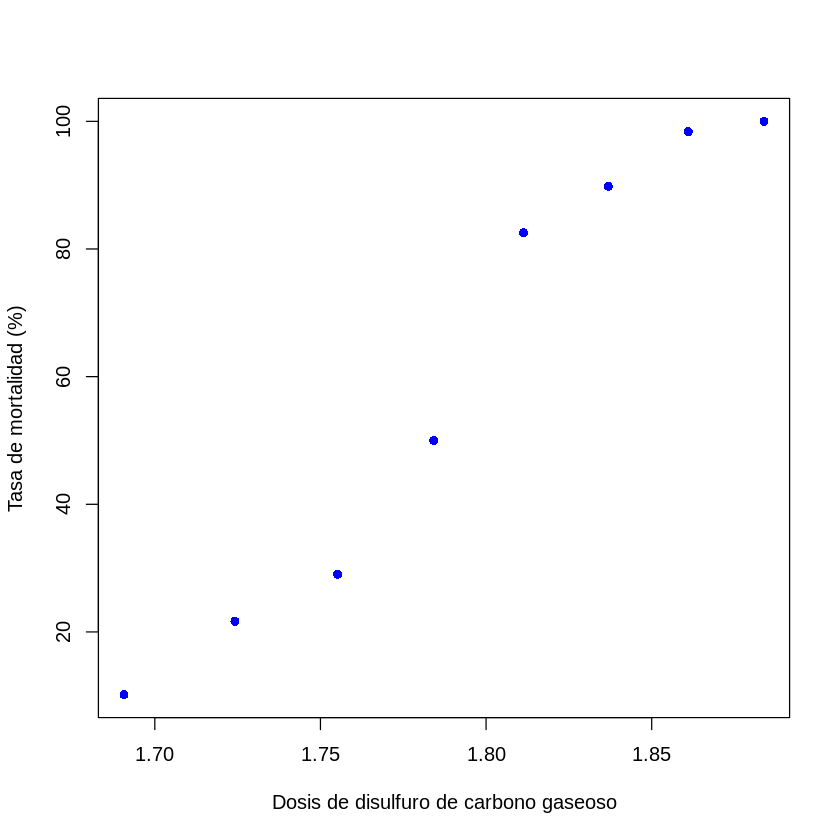

In [ ]:
###################### Introduciendo los datos ######################
totales <- c(59, 60, 62, 56, 63, 59, 62, 60)
exitos  <- c(6, 13, 18, 28, 52, 53, 61, 60)
dosis <- c(1.6907, 1.7242, 1.7552, 1.7842, 1.8113, 1.8369, 1.8610, 1.8839)

###################### Gráfico de los datos ######################
plot(dosis,100*exitos/totales,pch=16,
     xlab="Dosis de disulfuro de carbono gaseoso",ylab="Tasa de mortalidad (%)",col="blue")

In [ ]:
###################### Estimación de los modelos con funciones ######################
###################### de enlace logit, probit y cloglog ######################
fit1 <- glm(exitos/totales ~ dosis, weights=totales, family=binomial(link="logit"))
fit2 <- glm(exitos/totales ~ dosis, weights=totales, family=binomial(link="probit"))
fit3 <- glm(exitos/totales ~ dosis, weights=totales, family=binomial(link="cloglog"))
fit4 <- glm(exitos/totales ~ dosis, weights=totales, family=binomial(link="cauchit"))

In [ ]:
AIC(fit1,fit2,fit3,fit4)
BIC(fit1,fit2,fit3,fit4)

,df,AIC
,<dbl>,<dbl>
fit1,2,41.43027
fit2,2,40.31780
fit3,2,33.64448
fit4,2,50.35624


,df,BIC
,<dbl>,<dbl>
fit1,2,41.58915
fit2,2,40.47668
fit3,2,33.80336
fit4,2,50.51513


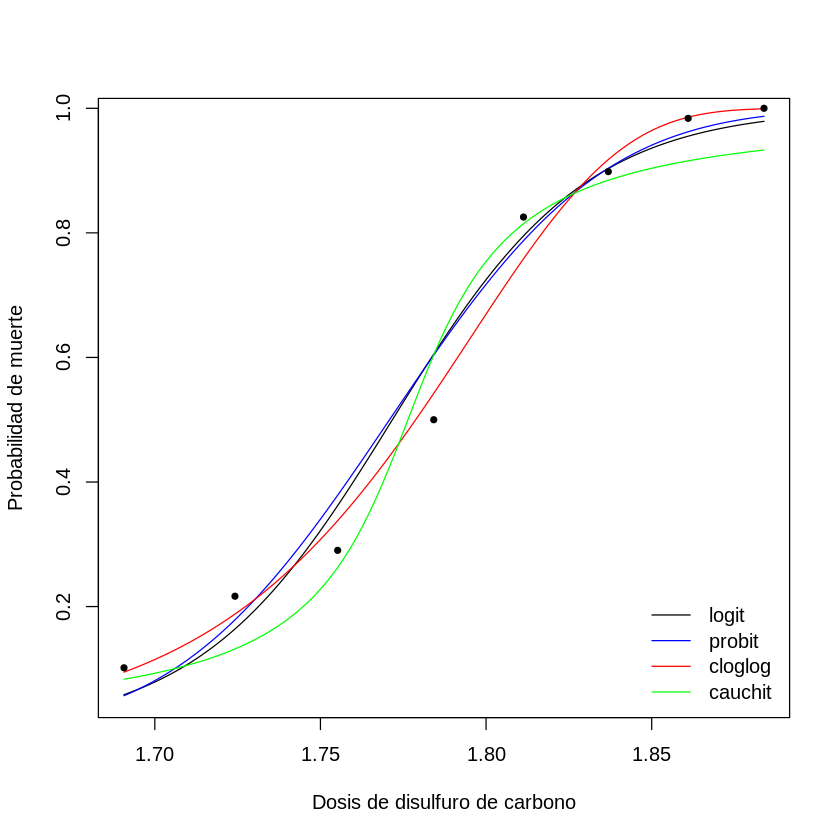

In [ ]:
###################### Gráfico de los modelos estimados con funciones ######################
###################### de enlace logit, probit y cloglog ######################
dosisg <- seq(min(dosis),max(dosis),length=100)
plot(dosisg,predict(fit1,data.frame(dosis=dosisg),type="response"),xlim=range(dosis),ylim=range(fitted(fit1)),
     col="black",type="l",xlab="Dosis de disulfuro de carbono",ylab="Probabilidad de muerte",main="")
lines(dosisg,predict(fit2,data.frame(dosis=dosisg),type="response"),col="blue")
lines(dosisg,predict(fit3,data.frame(dosis=dosisg),type="response"),col="red")
lines(dosisg,predict(fit4,data.frame(dosis=dosisg),type="response"),col="green")
points(dosis,exitos/totales,pch=20)
legend(x = "bottomright", legend = c("logit", "probit", "cloglog", "cauchit"), col = c("black", "blue", "red", "green"), lty = 1, bty = "n")



In [ ]:
###################### Comparando la calidad del ajuste ######################
gof_glm(fit3)


  Family:  binomial 
    Link:  cloglog 
                                                    Df   Value
Residual deviance                                    6  3.4464
Pearson's statistic                                  6  3.2947
Adjusted R-squared based on the residual deviance       0.9859
Adjusted R-squared based on the Pearson's statistic     0.9839
-2*log-Likelihood                                      29.6445
AIC                                                    33.6445
BIC                                                    33.8034




In [ ]:
###################### Resumen del modelo seleccionado ######################
summary(fit3)



Call:
glm(formula = exitos/totales ~ dosis, family = binomial(link = "cloglog"), 
    weights = totales)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -39.572      3.240  -12.21   <2e-16 ***
dosis         22.041      1.799   12.25   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 284.2024  on 7  degrees of freedom
Residual deviance:   3.4464  on 6  degrees of freedom
AIC: 33.644

Number of Fisher Scoring iterations: 4


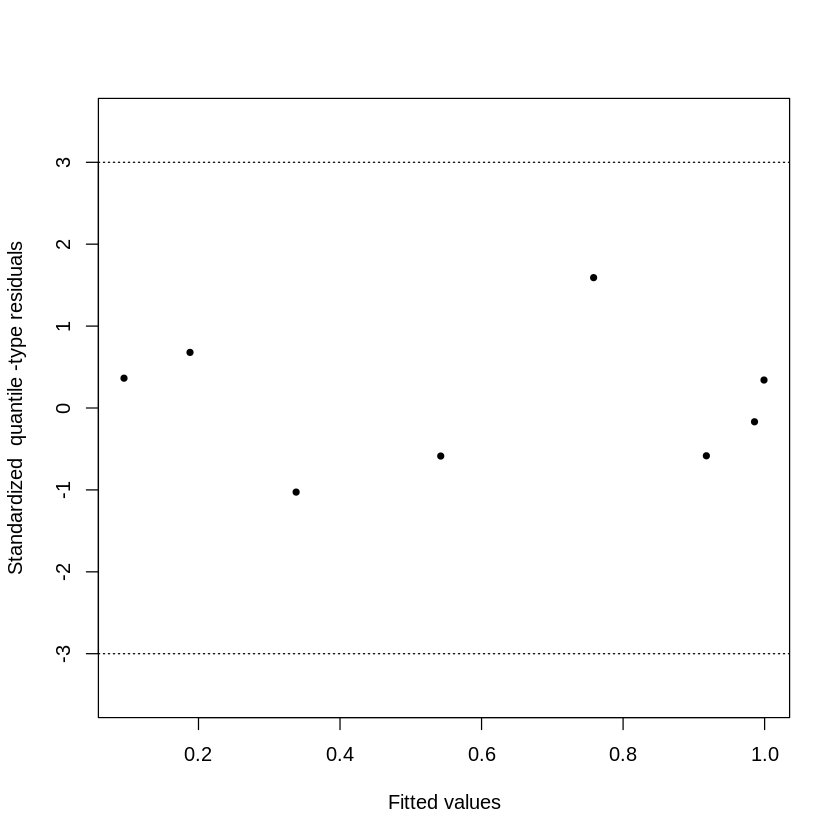

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Análisis de residuos ######################
residuals_glm(fit3)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


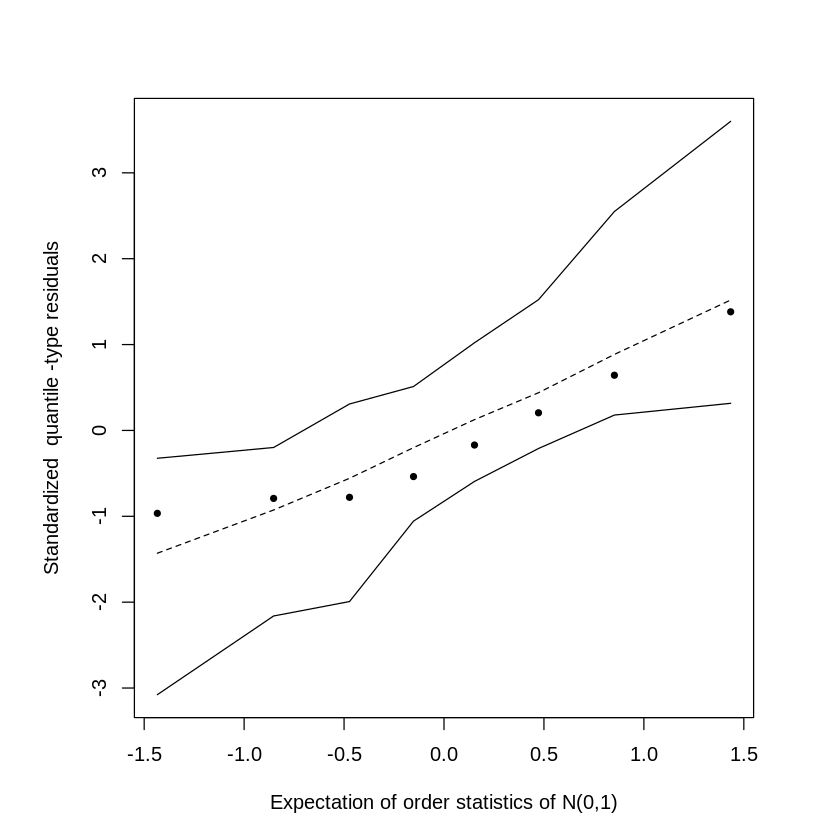

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit3,rep=100,conf=0.99)


## Ejemplo 2:Cangrejos

La respuesta para cada una de las 173 cangrejas hembras es 1 si tiene al menos un satélite (es decir, un cangrejo macho que puede fertilizar los huevos) y 0 en otros casos. Las variables explicativas son el color de la cangreja hembra y la anchura de su caparazón.

A continuación el enlace donde se encuentra el dataset: [CRABS](https://drive.google.com/file/d/1LjUgh7pgEj5xhIXLVE0R_micc-23tH4s/view?usp=share_link)

In [ ]:
###################### Lectura de los datos ######################
cangrejos <- read.table("crabs.txt",head=TRUE)
satellite <- ifelse(cangrejos$y>0,1,0)
col <- ifelse(cangrejos$color==4,"dark  ","bright")
cangrejos <- as.data.frame(cbind(cangrejos,satellite,col))
str(cangrejos)

'data.frame':	173 obs. of  7 variables:
 $ y        : int  8 0 9 0 4 0 0 0 0 0 ...
 $ weight   : num  3.05 1.55 2.3 2.1 2.6 2.1 2.35 1.9 1.95 2.15 ...
 $ width    : num  28.3 22.5 26 24.8 26 23.8 26.5 24.7 23.7 25.6 ...
 $ color    : int  2 3 1 3 3 2 1 3 2 3 ...
 $ spine    : int  3 3 1 3 3 3 1 2 1 3 ...
 $ satellite: num  1 0 1 0 1 0 0 0 0 0 ...
 $ col      : chr  "bright" "bright" "bright" "bright" ...


In [ ]:
head(cangrejos)

,y,weight,width,color,spine,satellite,col
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>
1,8,3.05,28.3,2,3,1,bright
2,0,1.55,22.5,3,3,0,bright
3,9,2.30,26.0,1,1,1,bright
4,0,2.10,24.8,3,3,0,bright
5,4,2.60,26.0,3,3,1,bright
6,0,2.10,23.8,2,3,0,bright


In [ ]:
###################### Estimación del modelo ######################
fit1 <- glm(satellite ~ width*weight*col, family=binomial(link="logit"),data=cangrejos)
fit2 <- glm(satellite ~ width*weight*col, family=binomial(link="probit"),data=cangrejos)
fit3 <- glm(satellite ~ width*weight*col, family=binomial(link="cloglog"),data=cangrejos)

In [ ]:
AIC(fit1,fit2,fit3)
BIC(fit1,fit2,fit3)

,df,AIC
,<dbl>,<dbl>
fit1,8,198.6441
fit2,8,198.6099
fit3,8,198.5219


,df,BIC
,<dbl>,<dbl>
fit1,8,223.8704
fit2,8,223.8362
fit3,8,223.7482


In [ ]:
step_glm(fit1,direction="forward",criterion="AIC")


  Family:  binomial 
    Link:  cloglog 

Initial model:
satellite ~ 1  

Step 0 :    
         Df      AIC      BIC   Deviance+ Pearson^  p-value*
+ width   1   197.2753 203.5818    0.1389   0.0434 1.642e-07
+ weight  1   199.2318 205.5384    0.1302   0.0162 2.759e-07
+ col     1   218.7929 225.0995    0.0430  -0.0058    0.0047
<none>        227.7585 230.9118    0.0000   0.0000          

Step 1 :  + width 
         Df      AIC      BIC   Deviance+ Pearson^ p-value*
+ col     1   192.4524 201.9123    0.1644   0.0255   0.0213
<none>        197.2753 203.5818    0.1389   0.0434         
+ weight  1   198.1214 207.5813    0.1390   0.0264   0.3128

Step 2 :  + col 
            Df      AIC      BIC   Deviance+ Pearson^ p-value*
<none>           192.4524 201.9123    0.1644   0.0255         
+ weight     1   193.4419 206.0551    0.1640   0.0050   0.3411
+ width:col  1   194.1533 206.7664    0.1608   0.0242   0.5612

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared bas

In [ ]:
step_glm(fit2,direction="forward",criterion="AIC")


  Family:  binomial 
    Link:  probit 

Initial model:
satellite ~ 1  

Step 0 :    
         Df      AIC      BIC   Deviance+ Pearson^  p-value*
+ width   1   198.0357 204.3423    0.1355   0.0394 1.951e-07
+ weight  1   199.4621 205.7687    0.1291   0.0220 3.250e-07
+ col     1   218.7929 225.0995    0.0430  -0.0058    0.0012
<none>        227.7585 230.9118    0.0000   0.0000          

Step 1 :  + width 
         Df      AIC      BIC   Deviance+ Pearson^ p-value*
+ col     1   193.7202 203.1801    0.1587   0.0201   0.0147
<none>        198.0357 204.3423    0.1355   0.0394         
+ weight  1   198.6092 208.0690    0.1368   0.0245   0.2313

Step 2 :  + col 
            Df      AIC      BIC   Deviance+ Pearson^ p-value*
<none>           193.7202 203.1801    0.1587   0.0201         
+ width:col  1   194.4969 207.1101    0.1592   0.0231   0.2563
+ weight     1   194.5472 207.1604    0.1590   0.0049   0.2762

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared base

In [ ]:
step_glm(fit3,direction="backward",criterion="AIC")


  Family:  binomial 
    Link:  cloglog 

Initial model:
satellite ~ 1 + width + weight + col + width:weight + width:col + weight:col + width:weight:col 

Step 0 :    
                   Df      AIC      BIC   Deviance+ Pearson^ p-value*
- width:weight:col  1   198.4266 220.4996    0.1536  -0.0133   0.1067
<none>                  198.5219 223.7482    0.1572  -0.0183         

Step 1 :  - width:weight:col 
               Df      AIC      BIC   Deviance+ Pearson^ p-value*
- width:weight  1   196.4320 215.3518    0.1586  -0.0068   0.9393
- width:col     1   196.5284 215.4482    0.1582  -0.0059   0.7611
- weight:col    1   197.2278 216.1475    0.1550  -0.0037   0.3904
<none>              198.4266 220.4996    0.1536  -0.0133         

Step 2 :  - width:weight 
             Df      AIC      BIC   Deviance+ Pearson^ p-value*
- width:col   1   194.5298 210.2963    0.1632   0.0003   0.7655
- weight:col  1   195.2339 211.0004    0.1600   0.0025   0.3898
<none>            196.4320 215.3518    0.

In [ ]:
fit1 <- glm(satellite ~ width + col, family=binomial(link="logit"),data=cangrejos)
fit2 <- glm(satellite ~ width + col, family=binomial(link="probit"),data=cangrejos)
fit3 <- glm(satellite ~ width + col, family=binomial(link="cloglog"),data=cangrejos)

In [ ]:
AIC(fit1,fit2,fit3)
BIC(fit1,fit2,fit3)

,df,AIC
,<dbl>,<dbl>
fit1,3,193.9579
fit2,3,193.7202
fit3,3,192.4524


,df,BIC
,<dbl>,<dbl>
fit1,3,203.4178
fit2,3,203.1801
fit3,3,201.9123


In [ ]:
###################### Comparando la calidad del ajuste ######################
gof_glm(fit3)


  Family:  binomial 
    Link:  cloglog 
                                                     Df    Value
Residual deviance                                   170 186.4524
Pearson's statistic                                 170 166.6211
Adjusted R-squared based on the residual deviance         0.1644
Adjusted R-squared based on the Pearson's statistic       0.0255
-2*log-Likelihood                                       186.4524
AIC                                                     192.4524
BIC                                                     201.9123




In [ ]:
gof_glm(fit2)


  Family:  binomial 
    Link:  probit 
                                                     Df    Value
Residual deviance                                   170 187.7202
Pearson's statistic                                 170 167.5567
Adjusted R-squared based on the residual deviance         0.1587
Adjusted R-squared based on the Pearson's statistic       0.0201
-2*log-Likelihood                                       187.7202
AIC                                                     193.7202
BIC                                                     203.1801




In [ ]:
###################### Resumen del modelo seleccionado ######################
summary(fit3)


Call:
glm(formula = satellite ~ width + col, family = binomial(link = "cloglog"), 
    data = cangrejos)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -7.62635    1.61150  -4.732 2.22e-06 ***
width        0.29634    0.06072   4.881 1.06e-06 ***
coldark     -0.92458    0.40168  -2.302   0.0213 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 225.76  on 172  degrees of freedom
Residual deviance: 186.45  on 170  degrees of freedom
AIC: 192.45

Number of Fisher Scoring iterations: 5


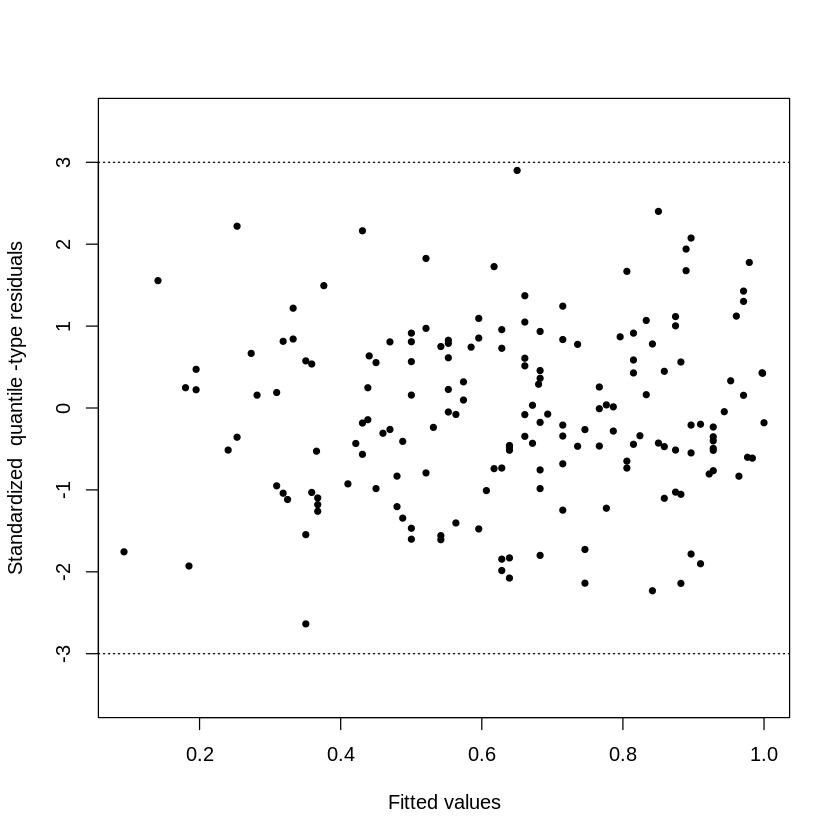

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Análisis de residuos ######################
residuals_glm(fit3)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


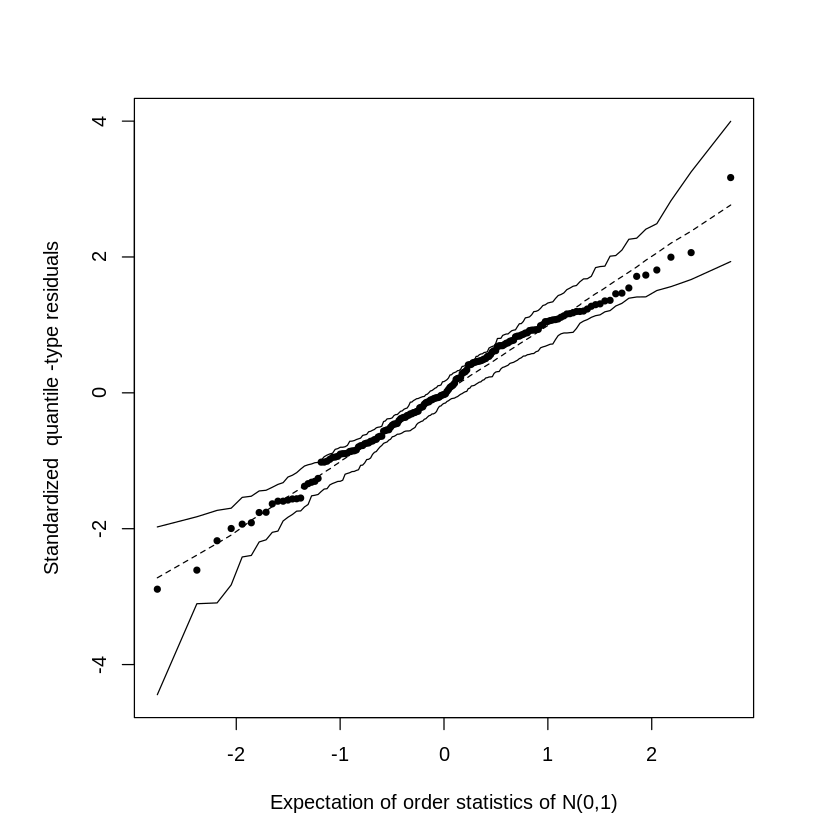

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit3,rep=100,conf=0.99)


## Ejemplo 3: Premios

En estos datos, la variable respuesta es la cantidad de premios obtenidos por cada uno de 200 estudiantes en una escuela secundaria en un año, y las covariables son el puntaje de los estudiantes en su examen final de matemáticas, y una variable categórica con tres niveles que indica el tipo de programa en el que se inscribieron los estudiantes, donde 1, 2 y 3 representan, respectivamente, General, Académico y Vocacional. El objetivo principal es explicar el número esperado de premios en función del puntaje en el examen final de matemáticas y el tipo de programa en el que se inscribieron los estudiantes.

A continuación el enlace donde se encuentra el dataset: [AWARDS](https://drive.google.com/file/d/1ekAdKiHmI0PAd4w8d0dQ-QqM3mzIW1Hu/view?usp=share_link)

In [ ]:
###################### Lectura de los datos ######################
awards <- read.table("awards.txt",head=TRUE)
programa <- rep("General   ",nrow(awards))
programa <- ifelse(awards$prog==2,"Academico ",programa)
programa <- ifelse(awards$prog==3,"Vocacional",programa)
awards <- as.data.frame(cbind(awards,programa))
str(awards)

'data.frame':	200 obs. of  4 variables:
 $ num_awards: int  0 0 0 0 0 0 0 0 0 0 ...
 $ prog      : int  3 1 3 3 3 1 3 3 3 3 ...
 $ math      : int  41 41 44 42 40 42 46 40 33 46 ...
 $ programa  : chr  "Vocacional" "General   " "Vocacional" "Vocacional" ...


In [ ]:
head(awards)

,num_awards,prog,math,programa
,<int>,<int>,<int>,<chr>
1,0,3,41,Vocacional
2,0,1,41,General
3,0,3,44,Vocacional
4,0,3,42,Vocacional
5,0,3,40,Vocacional
6,0,1,42,General


In [ ]:
awards$programa <- as.factor(awards$programa)
awards$programa <- relevel(awards$programa,ref="General   ")

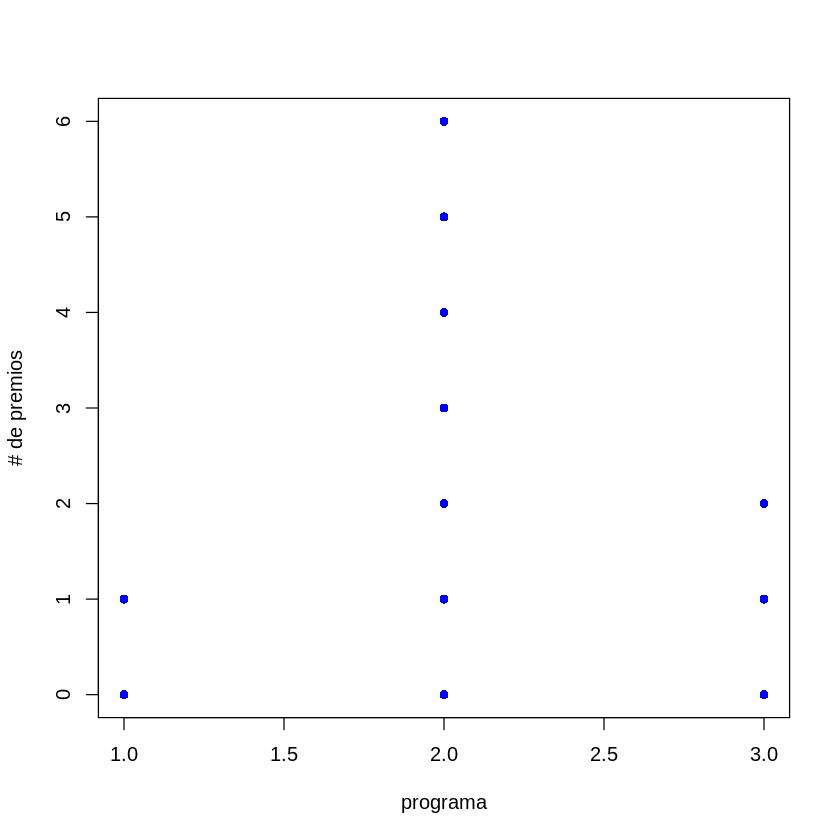

In [ ]:
plot(awards$prog,awards$num_awards,pch=16,
     xlab="programa",ylab="# de premios",col="blue")

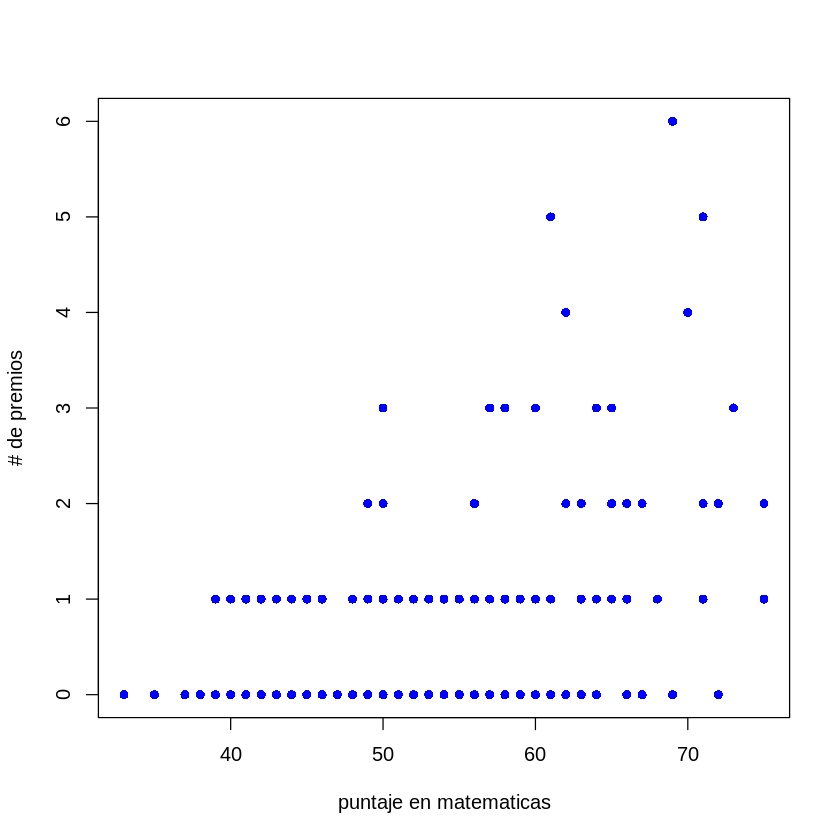

In [ ]:
plot(awards$math,awards$num_awards,pch=16,
     xlab="puntaje en matematicas",ylab="# de premios",col="blue")

In [ ]:
###################### Estimación del modelo ######################
fit1 <- glm(num_awards ~ programa*math, family=poisson(link="log"), data=awards)

step_glm(fit1,direction="backward",criterion="BIC")



  Family:  poisson 
    Link:  log 

Initial model:
num_awards ~ 1 + programa + math + programa:math 

Step 0 :    
                Df      BIC      AIC   Deviance+ Pearson^ p-value*
- programa:math  2   386.6978 373.5045    0.3314   0.3849   0.8364
<none>               396.9464 377.1565    0.3257   0.3902         

Step 1 :  - programa:math 
           Df      BIC      AIC   Deviance+ Pearson^  p-value*
<none>          386.6978 373.5045    0.3314   0.3849          
- programa  2   390.6728 384.0762    0.2872   0.3430    0.0021
- math      1   426.4098 416.5149    0.1767   0.2481 3.625e-11

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
num_awards ~ 1 + programa + math 



In [ ]:
step_glm(fit1,direction="forward",criterion="BIC")


  Family:  poisson 
    Link:  log 

Initial model:
num_awards ~ 1  

Step 0 :    
           Df      BIC      AIC   Deviance+ Pearson^  p-value*
+ math      1   390.6728 384.0762    0.2872   0.3430    0.0000
+ programa  2   426.4098 416.5149    0.1767   0.2481 2.253e-09
<none>          469.0254 465.7271    0.0000   0.0000          

Step 1 :  + math 
           Df      BIC      AIC   Deviance+ Pearson^ p-value*
+ programa  2   386.6978 373.5045    0.3314   0.3849   0.0021
<none>          390.6728 384.0762    0.2872   0.3430         

Step 2 :  + programa 
                Df      BIC      AIC   Deviance+ Pearson^ p-value*
<none>               386.6978 373.5045    0.3314   0.3849         
+ programa:math  2   396.9464 377.1565    0.3257   0.3902   0.8364

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
num_awards ~ 1 + math + programa 



In [ ]:
fit11 <- glm(num_awards ~ programa + math, family=poisson(link="log"), data=awards)
###################### Resumen del modelo seleccionado ######################
summary(fit11)


Call:
glm(formula = num_awards ~ programa + math, family = poisson(link = "log"), 
    data = awards)

Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -5.24712    0.65845  -7.969 1.60e-15 ***
programaAcademico   1.08386    0.35825   3.025  0.00248 ** 
programaVocacional  0.36981    0.44107   0.838  0.40179    
math                0.07015    0.01060   6.619 3.63e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 287.67  on 199  degrees of freedom
Residual deviance: 189.45  on 196  degrees of freedom
AIC: 373.5

Number of Fisher Scoring iterations: 6


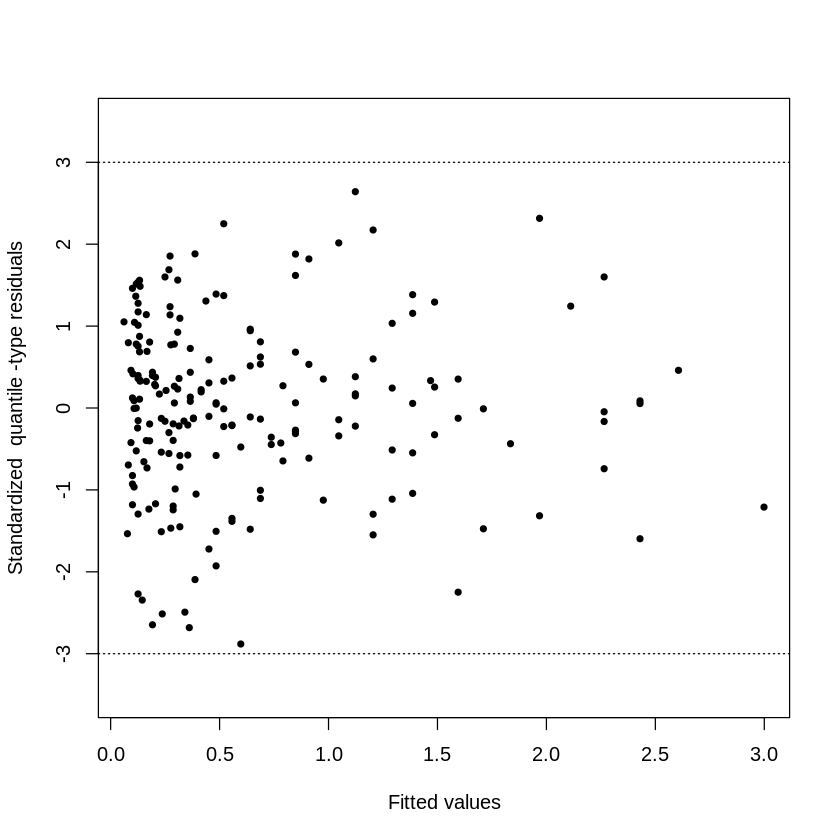

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Gráfico de residuos ######################
residuals_glm(fit11)


  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


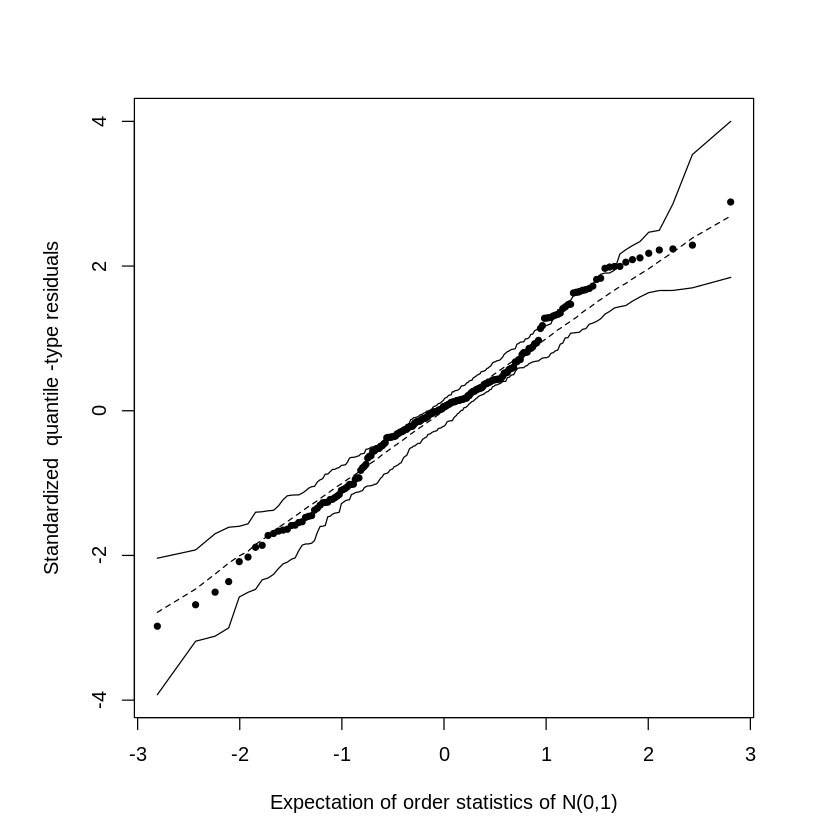

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit11,rep=100,conf=0.99)

## Ejemplo 4: Cancer de pulmón

Incidencia  Cáncer de pulmón en cuatro ciudades danesas según rangos de edad.

A continuación el enlace donde se encuentra el dataset: [LUNGS](https://drive.google.com/file/d/1iUFOf1yzfYHaDFoQp3wxN9cVqY6gz2jG/view?usp=share_link)

In [ ]:
###################### Lectura de los datos ######################
pulmon <- read.table("lungs.txt",head=TRUE)
head(pulmon)

,cases,pop,age,city
,<int>,<int>,<chr>,<chr>
1,11,3059,40_54,Fredericia
2,11,800,55_59,Fredericia
3,11,710,60_64,Fredericia
4,10,581,65_69,Fredericia
5,11,509,70_74,Fredericia
6,10,605,74_+,Fredericia


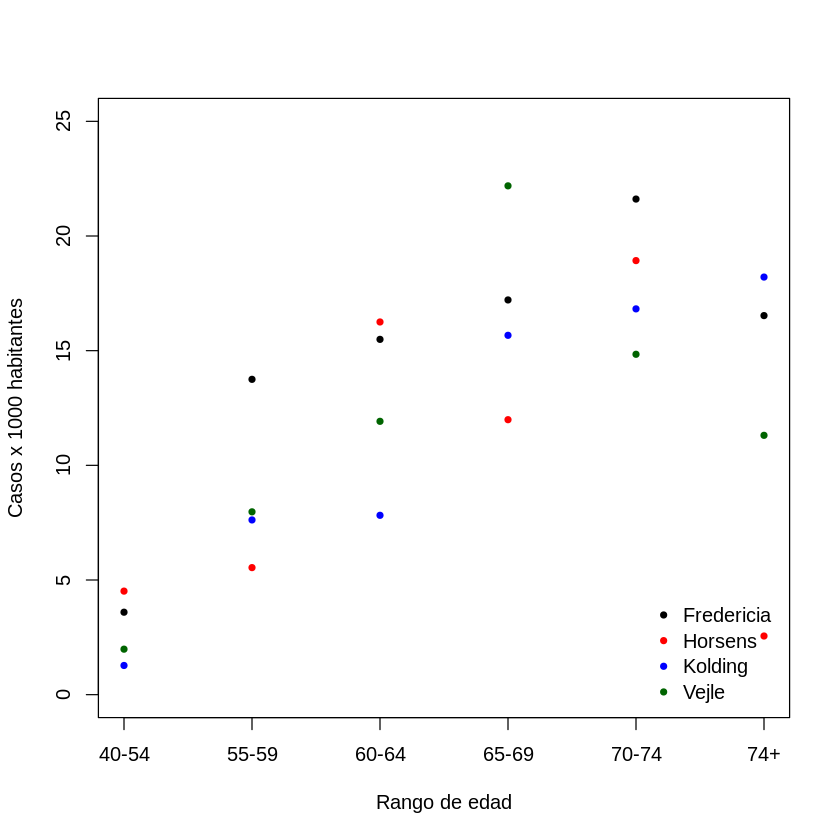

In [ ]:
###################### Gráfico de los datos ######################
with(pulmon,{
plot(1:6,1000*cases[city=='Fredericia']/pop[city=='Fredericia'], pch=20, xaxt="n",
     ylab="Casos x 1000 habitantes", xlab="Rango de edad", xlim=c(1,6), ylim=c(0,25))
points(1:6,1000*cases[city=='Horsens']/pop[city=='Horsens'], pch=20, col="red")
points(1:6,1000*cases[city=='Kolding']/pop[city=='Kolding'], pch=20, col="blue")
points(1:6,1000*cases[city=='Vejle']/pop[city=='Vejle'], pch=20, col="dark green")})
axis(1, at=1:6, labels=c('40-54','55-59','60-64','65-69','70-74','74+'))
legend(x = "bottomright",col=c("black","red","blue","dark green"),
       legend=c("Fredericia","Horsens","Kolding","Vejle"), bty="n",pch=20)

In [ ]:
###################### Ajuste del modelo ######################
fit1 <- glm(cases ~ city + age + offset(log(pop)), family=poisson(link=log), data=pulmon)

fit2 <- glm(cases ~ age + offset(log(pop)), family=poisson(link=log), data=pulmon)

En el contexto de un modelo de Poisson, un offset es a menudo utilizado cuando la variable respuesta representa un conteo y queremos modelar la tasa en lugar del conteo total. Por ejemplo, si cases representa el número de casos de una enfermedad en diferentes ciudades, y pop representa la población de esas ciudades, entonces log(pop) podría ser utilizado como un offset para modelar el número de casos en relación al tamaño de la población.

Al incluir log(pop) como un offset, estás modelando los logaritmos de las tasas de casos en lugar de los conteos de casos. Esto es útil porque los modelos de Poisson asumen que la varianza es igual a la media, lo cual es más razonable para tasas que para conteos cuando las poblaciones son diferentes.

Entonces, el término offset(log(pop)) ajusta el modelo para tener en cuenta el tamaño de la población, permitiendo una comparación más justa de las tasas de casos entre diferentes ciudades.

In [ ]:
summary(fit1)



Call:
glm(formula = cases ~ city + age + offset(log(pop)), family = poisson(link = log), 
    data = pulmon)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -5.6321     0.2003 -28.125  < 2e-16 ***
cityHorsens  -0.3301     0.1815  -1.818   0.0690 .  
cityKolding  -0.3715     0.1878  -1.978   0.0479 *  
cityVejle    -0.2723     0.1879  -1.450   0.1472    
age55_59      1.1010     0.2483   4.434 9.23e-06 ***
age60_64      1.5186     0.2316   6.556 5.53e-11 ***
age65_69      1.7677     0.2294   7.704 1.31e-14 ***
age70_74      1.8569     0.2353   7.891 3.00e-15 ***
age74_+       1.4197     0.2503   5.672 1.41e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  23.447  on 15  degrees of freedom
AIC: 137.84

Number of Fisher Scoring iterations: 5


In [ ]:
summary(fit2)



Call:
glm(formula = cases ~ age + offset(log(pop)), family = poisson(link = log), 
    data = pulmon)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -5.8623     0.1741 -33.676  < 2e-16 ***
age55_59      1.0823     0.2481   4.363 1.29e-05 ***
age60_64      1.5017     0.2314   6.489 8.66e-11 ***
age65_69      1.7503     0.2292   7.637 2.22e-14 ***
age70_74      1.8472     0.2352   7.855 4.00e-15 ***
age74_+       1.4083     0.2501   5.630 1.80e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  28.307  on 18  degrees of freedom
AIC: 136.69

Number of Fisher Scoring iterations: 5


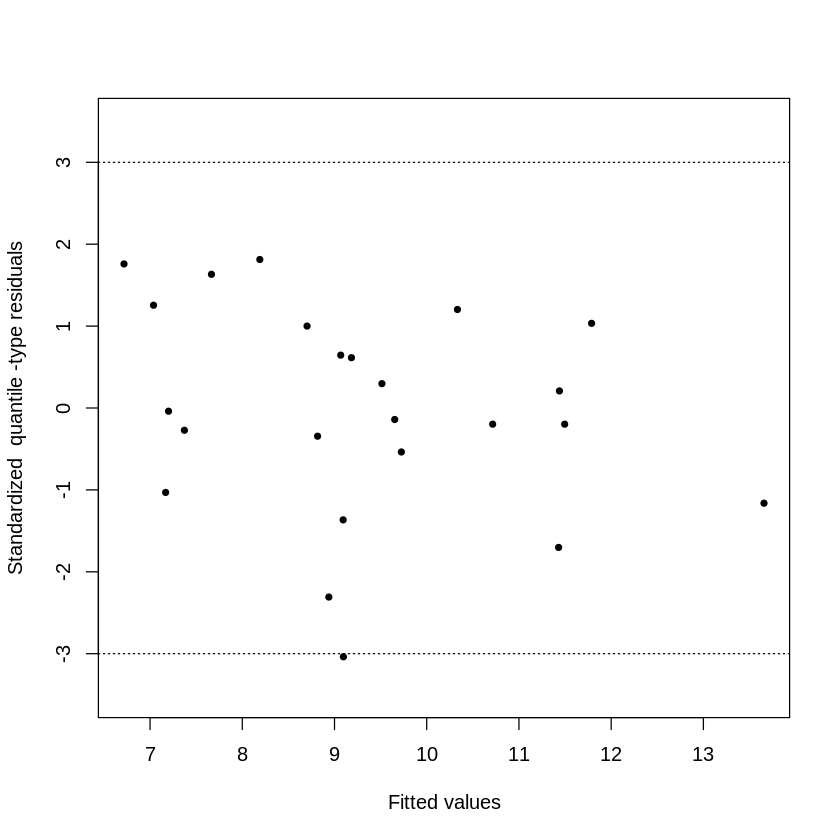

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Gráfico de residuos ######################
residuals_glm(fit2,identify=1)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


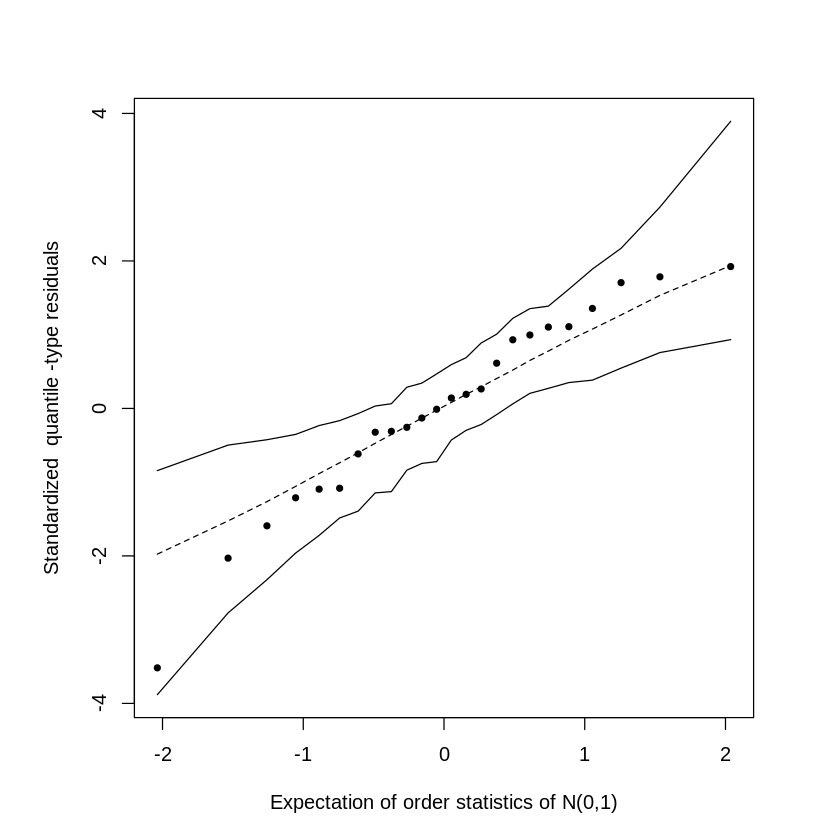

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit2,rep=1000,conf=0.99)

In [ ]:
###################### Interpretación de parámetros (1) ######################
exp(coef(fit2)[2])

##### La incidencia esperada de cáncer de pulmón en individuos de 55-59 años es, aproximadamente,
##### 2.95 veces la incidencia esperada en individuos de 40-54 años.


age55_59 
2.951584

In [ ]:
###################### Interpretación de parámetros (2) ######################
exp(coef(fit2)[3])

##### La incidencia esperada de cáncer de pulmón en individuos de 60-64 años es, aproximadamente,
##### 4.49 veces la incidencia esperada en individuos de 40-54 años.

age60_64 
4.489204

In [ ]:
###################### Interpretación de parámetros (3) ######################
exp(coef(fit2)[4])

##### La incidencia esperada de cáncer de pulmón en individuos de 65-69 años es, aproximadamente,
##### 5.76 veces la incidencia esperada en individuos de 40-54 años.

age65_69 
5.756252

## Ejemplo 5: Acero Endurecido

Estos datos consisten en tiempos de fallo en una fatiga de contacto rodante de diez especímenes de acero endurecido probados en cada uno de cuatro valores de tensión de contacto. Los datos se obtuvieron utilizando una prueba de contacto rodante de 4 bolas.

A continuación el enlace donde se encuentra el dataset: [STEEL](https://drive.google.com/file/d/13fGpR9HdbSNggqEUQyCg5hz5BRGkiHKb/view?usp=share_link)

In [ ]:
steel <- read.table("Steel.txt", header=TRUE)
str(steel)

'data.frame':	40 obs. of  2 variables:
 $ stress: num  0.87 0.87 0.87 0.87 0.87 0.87 0.87 0.87 0.87 0.87 ...
 $ life  : num  1.67 2.2 2.51 3 2.9 4.7 7.53 14.7 27.8 37.4 ...


In [ ]:
head(steel)

,stress,life
,<dbl>,<dbl>
1,0.87,1.67
2,0.87,2.20
3,0.87,2.51
4,0.87,3.00
5,0.87,2.90
6,0.87,4.70


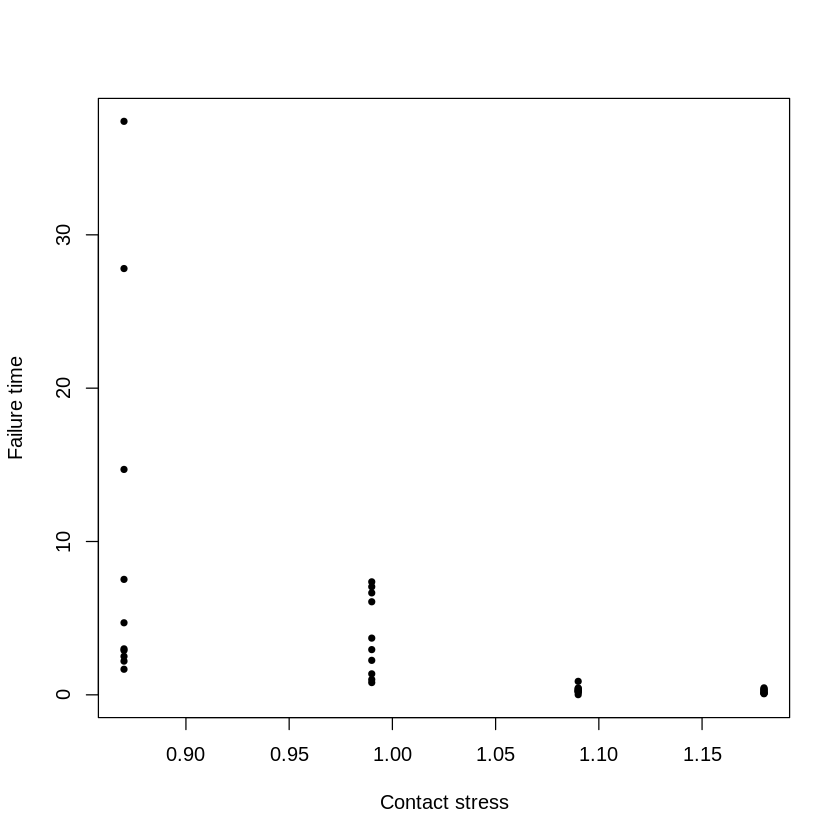

In [ ]:
###################### Gráfico de los datos ######################
with(steel,{plot(stress,life,xlab="Contact stress",ylab="Failure time",
     ylim=range(life),pch=20)})


In [ ]:
###################### Ajuste del modelo ######################
fit1 <- glm(life ~ stress, data=steel, family=Gamma("inverse"))
fit2 <- glm(life ~ stress, data=steel, family=Gamma("log"))
fit3 <- glm(life ~ stress, data=steel, family=Gamma("identity"), mustart=fitted(fit2))

AIC(fit1,fit2,fit3)
BIC(fit1,fit2,fit3)

,df,AIC
,<dbl>,<dbl>
fit1,3,136.1048
fit2,3,114.1519
fit3,3,131.5274


,df,BIC
,<dbl>,<dbl>
fit1,3,141.1715
fit2,3,119.2186
fit3,3,136.5940


In [ ]:
###################### Comparando la calidad del ajuste ######################
gof_glm(fit2)



  Family:  Gamma 
    Link:  log 
                                                    Df    Value
Residual deviance                                   38  34.2258
Deviance-based estimate of dispersion parameter          0.9007
Pearson's statistic                                 38  29.3014
Pearson-based estimate of dispersion parameter           0.7711
Adjusted R-squared based on the residual deviance        0.6808
Adjusted R-squared based on the Pearson's statistic      0.8062
-2*log-Likelihood                                      108.1519
AIC                                                    114.1519
BIC                                                    119.2186




In [ ]:
###################### Comparando la calidad del ajuste ######################
gof_glm(fit3)



  Family:  Gamma 
    Link:  identity 
                                                    Df    Value
Residual deviance                                   38  49.7834
Deviance-based estimate of dispersion parameter          1.3101
Pearson's statistic                                 38  58.5768
Pearson-based estimate of dispersion parameter           1.5415
Adjusted R-squared based on the residual deviance        0.5357
Adjusted R-squared based on the Pearson's statistic      0.6126
-2*log-Likelihood                                      125.5274
AIC                                                    131.5274
BIC                                                    136.5940




In [ ]:
###################### Resumen del modelo seleccionado ######################
summary(fit2)


Call:
glm(formula = life ~ stress, family = Gamma("log"), data = steel)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   14.186      1.250   11.35 9.02e-14 ***
stress       -13.383      1.203  -11.12 1.63e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Gamma family taken to be 0.7710894)

    Null deviance: 110.033  on 39  degrees of freedom
Residual deviance:  34.226  on 38  degrees of freedom
AIC: 114.15

Number of Fisher Scoring iterations: 6


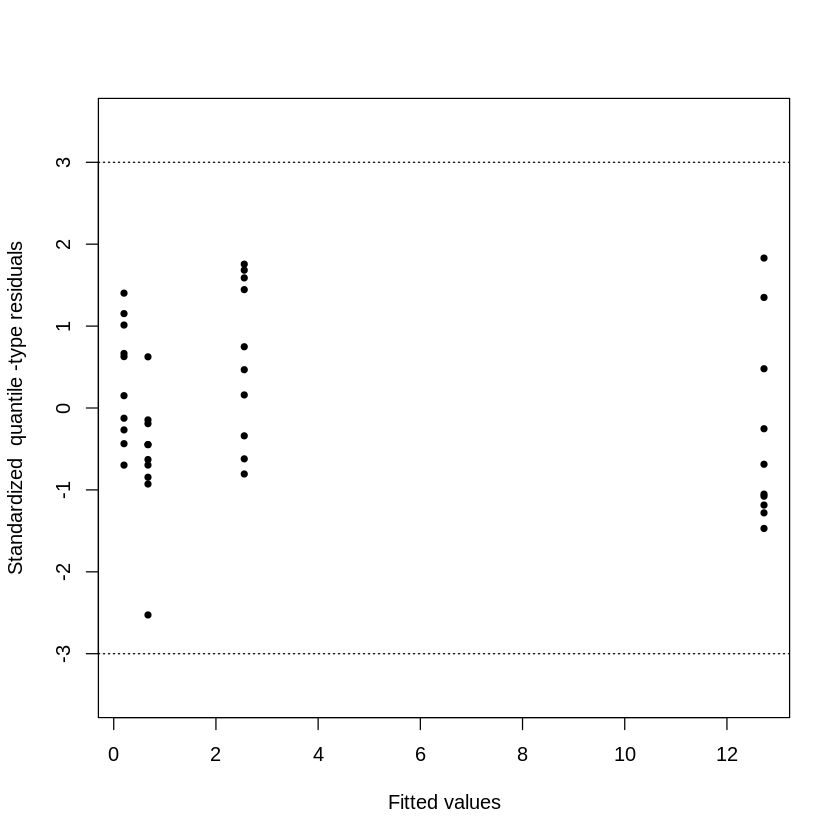

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Gráfico de residuos ######################
residuals_glm(fit2,identify=1)

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


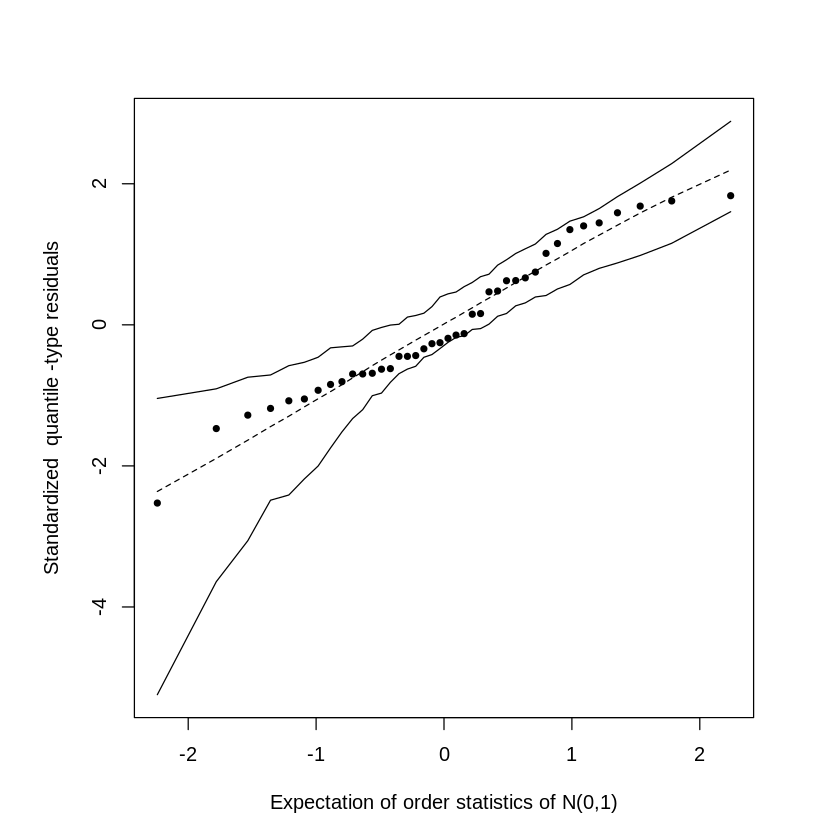

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit2,rep=1000,conf=0.95)

In [ ]:
###################### Interpretación de parámetros ######################
exp(coef(fit2)[2]*0.1)

##### Por cada 0.1 unidades que aumenta el stress de contacto la vida esperada de la pieza de acero endurecido
##### disminuye, aproximadamente, 73.8%.

stress 
0.2623009

## Ejemplo 6: Leucemia

Estos datos describen los tiempos de sobrevivencia, en semanas, para 33 pacientes con leucemia. La leucemia es un cancer caracterizado por una proliferacion excesiva de globulos blancos, de hecho, cuanto mayor es el recuento de globulos blancos mas severa es la enfermedad.

Entonces, para pronosticar el tiempo de sobrevivencia de un paciente con leucemia es razonable basarse en el recuento de globulos blancos y otras variables que son indicadoras de la progresion de la enfermedad.

Siendo asi, la respuesta es el tiempo de sobrevivencia y las covariables son el logaritmo natural del conteo de globulos blancos, y la presencia o ausencia de una caracteristica morfologica en los globulos blancos.

A continuación el enlace donde se encuentra el dataset: [LEUKEMIA](https://drive.google.com/file/d/18EJFw8rdGdFSxsjLLm-8HLCfszY34qko/view?usp=share_link)

In [ ]:
leucemia <- read.table("leukemia.txt",head=TRUE)
str(leucemia)

'data.frame':	33 obs. of  3 variables:
 $ AG  : chr  "AG_pos" "AG_pos" "AG_pos" "AG_pos" ...
 $ time: int  65 156 100 134 16 108 121 4 39 143 ...
 $ cell: num  2.3 0.75 4.3 2.6 6 10.5 10 17 5.4 7 ...


In [ ]:
head(leucemia)

,AG,time,cell
,<chr>,<int>,<dbl>
1,AG_pos,65,2.30
2,AG_pos,156,0.75
3,AG_pos,100,4.30
4,AG_pos,134,2.60
5,AG_pos,16,6.00
6,AG_pos,108,10.50


In [ ]:
###################### Estimación del modelo ######################
fit1 <- glm(time ~ AG*log(cell), family=Gamma(link="log"), data=leucemia)
fit2 <- glm(time ~ AG*log(cell), family=Gamma(link="inverse"), data=leucemia)

In [ ]:
step_glm(fit1,direction="backward",criterion="BIC")



  Family:  Gamma 
    Link:  log 

Initial model:
time ~ 1 + AG + log(cell) + AG:log(cell) 

Step 0 :    
               Df      BIC      AIC   Deviance+ Pearson^ p-value*
- AG:log(cell)  1   307.4731 301.4871    0.2603   0.1667   0.2450
<none>              309.2271 301.7445    0.2682   0.1449         

Step 1 :  - AG:log(cell) 
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
<none>           307.4731 301.4871    0.2603   0.1667         
- log(cell)  1   309.3409 304.8514    0.1797   0.2257   0.0269
- AG         1   310.7068 306.2173    0.1512   0.0469   0.0052

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
time ~ 1 + AG + log(cell) 



In [ ]:
step_glm(fit2,direction="backward",criterion="BIC")



  Family:  Gamma 
    Link:  inverse 

Initial model:
time ~ 1 + AG + log(cell) + AG:log(cell) 

Step 0 :    
               Df      BIC      AIC   Deviance+ Pearson^ p-value*
- AG:log(cell)  1   307.2059 301.2198    0.2653   0.2435   0.6116
<none>              310.4434 302.9608    0.2450   0.2047         

Step 1 :  - AG:log(cell) 
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
<none>           307.2059 301.2198    0.2653   0.2435         
- log(cell)  1   309.3409 304.8514    0.1797   0.2257   0.0083
- AG         1   311.0447 306.5552    0.1440   0.0646   0.0184

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
time ~ 1 + AG + log(cell) 



In [ ]:
step_glm(fit1,direction="forward",criterion="BIC")



  Family:  Gamma 
    Link:  log 

Initial model:
time ~ 1  

Step 0 :    
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
+ AG         1   309.3409 304.8514    0.1797   0.2257   0.0004
+ log(cell)  1   310.7068 306.2173    0.1512   0.0469   0.0062
<none>           315.1394 312.1464    0.0000   0.0000         

Step 1 :  + AG 
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
+ log(cell)  1   307.4731 301.4871    0.2603   0.1667   0.0269
<none>           309.3409 304.8514    0.1797   0.2257         

Step 2 :  + log(cell) 
               Df      BIC      AIC   Deviance+ Pearson^ p-value*
<none>              307.4731 301.4871    0.2603   0.1667         
+ AG:log(cell)  1   309.2271 301.7445    0.2682   0.1449   0.2450

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
time ~ 1 + AG + log(cell) 



In [ ]:
step_glm(fit2,direction="forward",criterion="BIC")


  Family:  Gamma 
    Link:  inverse 

Initial model:
time ~ 1  

Step 0 :    
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
+ AG         1   309.3409 304.8514    0.1797   0.2257   0.0063
+ log(cell)  1   311.0447 306.5552    0.1440   0.0646   0.0016
<none>           315.1394 312.1464    0.0000   0.0000         

Step 1 :  + AG 
            Df      BIC      AIC   Deviance+ Pearson^ p-value*
+ log(cell)  1   307.2059 301.2198    0.2653   0.2435   0.0083
<none>           309.3409 304.8514    0.1797   0.2257         

Step 2 :  + log(cell) 
               Df      BIC      AIC   Deviance+ Pearson^ p-value*
<none>              307.2059 301.2198    0.2653   0.2435         
+ AG:log(cell)  1   310.4434 302.9608    0.2450   0.2047   0.6116

+ Adjusted R-squared based on the residual deviance
^ Adjusted R-squared based on the Pearson statistic
* p-value of the Wald test

Final model:
time ~ 1 + AG + log(cell) 



In [ ]:
fit1 <- glm(time ~ AG + log(cell), family=Gamma(link="log"), data=leucemia)
fit2 <- glm(time ~ AG + log(cell), family=Gamma(link="inverse"), data=leucemia)

In [ ]:
AIC(fit1,fit2)
BIC(fit1,fit2)

,df,AIC
,<dbl>,<dbl>
fit1,4,301.4871
fit2,4,301.2198


,df,BIC
,<dbl>,<dbl>
fit1,4,307.4731
fit2,4,307.2059


In [ ]:
###################### Resumen del modelo seleccionado ######################
summary(fit2)


Call:
glm(formula = time ~ AG + log(cell), family = Gamma(link = "inverse"), 
    data = leucemia)

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  0.040210   0.014775   2.722   0.0107 *
AGAG_pos    -0.034415   0.014597  -2.358   0.0251 *
log(cell)    0.006105   0.002311   2.642   0.0130 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Gamma family taken to be 0.9874552)

    Null deviance: 58.138  on 32  degrees of freedom
Residual deviance: 40.044  on 30  degrees of freedom
AIC: 301.22

Number of Fisher Scoring iterations: 6


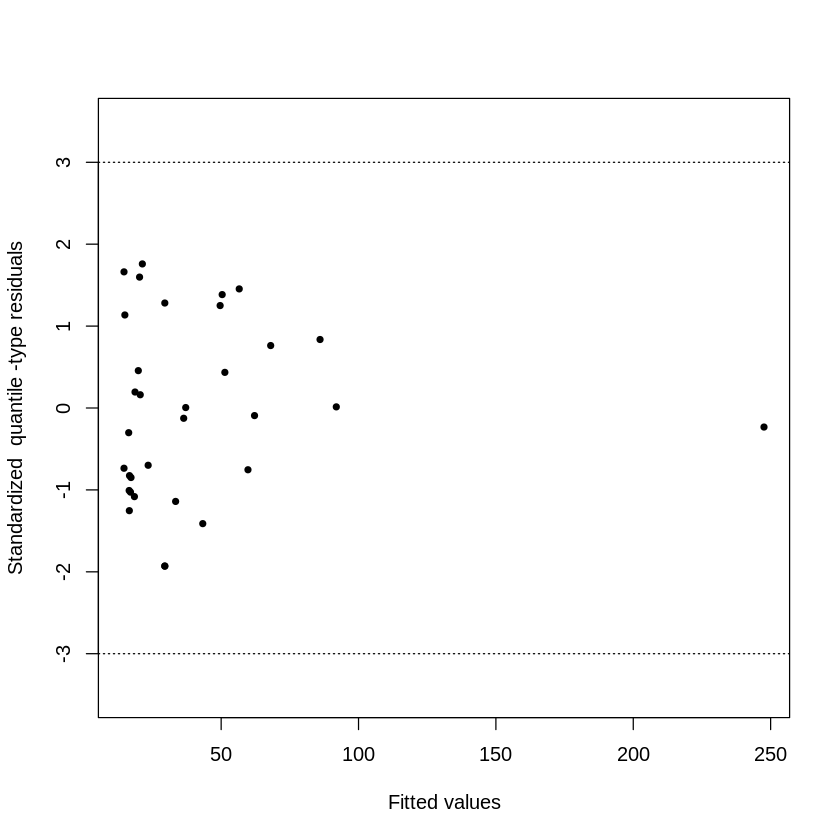

In [ ]:
################################# Diagnóstico del modelo seleccionado #################################
###################### Gráfico de residuos ######################
residuals_glm(fit2,identify=1)


  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100%


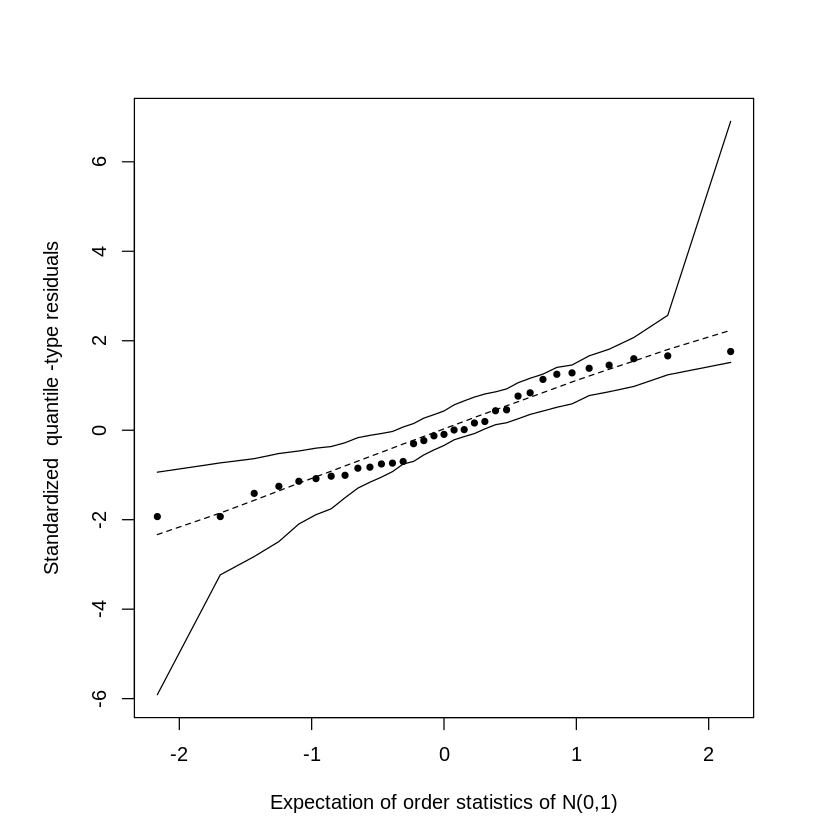

In [ ]:
###################### Gráfico de residuos con bandas de confianza ######################
envelope_glm(fit2,rep=1000,conf=0.95)
